# Савкина Мария, БД-251м
## Экзаменационное задание

## 1. Подготовка окружения

In [1]:
# Установка необходимых библиотек
!pip install pyspark matplotlib seaborn pandas numpy

In [2]:
# Импорт библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, stddev, hour, to_timestamp,
    regexp_extract, when, lit, window, desc, asc,
    sum as spark_sum,round as spark_round, rand, randn, least,
    date_format
)

from pyspark.sql.types import (
    StructType, StructField, StringType,
    IntegerType, TimestampType, DoubleType
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.feature import OneHotEncoder
from pyspark.ml.feature import VectorAssembler, StandardScaler, FeatureHasher

## 2. Инициализация Spark Session

In [3]:
# Создание SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("pw01_var25") \
    .master("local[*]") \
    .config("root.hadoop.fs.defaultFS", "hdfs://localhost:9000") \
    .config("spark.ui.port", "4040") \
    .config("spark.sql.shuffle.partitions", "300") \
    .config("spark.driver.memory", "8g") \
    .config("spark.driver.maxResultSize", "3g") \
    .getOrCreate()

print("SparkSession успешно запущен с расширенными настройками памяти.")

# Установка уровня логирования
spark.sparkContext.setLogLevel("WARN")

print(f"Spark Version: {spark.version}")
print(f"Spark UI: http://localhost:4040")

26/07/02 19:47:11 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 192.168.0.137 instead (on interface enp0s3)
26/07/02 19:47:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/02 19:47:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession успешно запущен с расширенными настройками памяти.
Spark Version: 3.5.3
Spark UI: http://localhost:4040


## 3. Загрузка данных

Выполнить команды из п.3 файла README.md


In [4]:
# Загрузка данных из HDFS в Spark DataFrame
hdfs_path = "hdfs://localhost:9000/user/hadoop/task11/input/digits.csv"

df = spark.read \
    .option("header", "false") \
    .option("inferSchema", "true") \
    .csv(hdfs_path)

# Переименовываем колонки: первая label, остальные pixel_0, pixel_1
old_columns = df.columns
new_columns = ["label"] + [f"pixel_{i}" for i in range(64)]

for old_col, new_col in zip(old_columns, new_columns):
    df = df.withColumnRenamed(old_col, new_col)

print("Схема данных:")
df.printSchema()

print("Общая статистика:")
print(f"Всего записей: {df.count():,}")

print("\nПримеры данных:")
df.show(5, truncate=False)

Схема данных:
root
 |-- label: integer (nullable = true)
 |-- pixel_0: double (nullable = true)
 |-- pixel_1: double (nullable = true)
 |-- pixel_2: double (nullable = true)
 |-- pixel_3: double (nullable = true)
 |-- pixel_4: double (nullable = true)
 |-- pixel_5: double (nullable = true)
 |-- pixel_6: double (nullable = true)
 |-- pixel_7: double (nullable = true)
 |-- pixel_8: double (nullable = true)
 |-- pixel_9: double (nullable = true)
 |-- pixel_10: double (nullable = true)
 |-- pixel_11: double (nullable = true)
 |-- pixel_12: double (nullable = true)
 |-- pixel_13: double (nullable = true)
 |-- pixel_14: double (nullable = true)
 |-- pixel_15: double (nullable = true)
 |-- pixel_16: double (nullable = true)
 |-- pixel_17: double (nullable = true)
 |-- pixel_18: double (nullable = true)
 |-- pixel_19: double (nullable = true)
 |-- pixel_20: double (nullable = true)
 |-- pixel_21: double (nullable = true)
 |-- pixel_22: double (nullable = true)
 |-- pixel_23: double (nullable =

26/07/02 19:47:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+
|label|pixel_0|pixel_1|pixel_2|pixel_3|pixel_4|pixel_5|pixel_6|pixel_7|pixel_8|pixel_9|pixel_10|pixel_11|pixel_12|pixel_13|pixel_14|pixel_15|pixel_16|pixel_17|pixel_18|pixel_19|pixel_20|pixel_21|pixel_22|pixel_23|pixel_24|pixel_25|pixel_26|pixel_27|pixel_28|pixel_29|pixel_30|pixel_31|pixel_32|pixel_33|pixel_34|pixel_35|pixel_36|pixel_37|pixel_38|pixel_39|pixel_40|pixel_41|pixel_42|pixel_43|pixel_44|pixel_45|pixel_46|pixel_

## 4. Очистка данных (обработка NULL, дубликатов)

In [5]:
# Удаление дубликатов
df = df.dropDuplicates()

# Удаляем строки с критическими пропусками (пропущена целевая метка)
df = df.dropna(subset=["label"])

# Пропущенные значения пикселей заполним нулями
pixel_cols = [f"pixel_{i}" for i in range(64)]
fill_values = {col_name: 0.0 for col_name in pixel_cols}

df = df.fillna(fill_values)


# Явное приведение типов

df = df.withColumn("label", col("label").cast(IntegerType()))

for col_name in pixel_cols:
    df = df.withColumn(col_name, col(col_name).cast(DoubleType()))

print("Количество строк после очистки:", df.count())

Количество строк после очистки: 1797


## 5. Кластеризация

In [6]:
#Сборка признаков в единый вектор

feature_columns = [c for c in df.columns if c != "label"]

assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

data = assembler.transform(df)

data.select("features").show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                                                                                                             |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(64,[2,3,4,9,10,11,12,13,17,18,19,20,21,25,26,27,28,29,30,33,34,35,37,38,41,42,43,44,45,46,50,51,52,53,58,59,60

In [7]:
#Масштабирование признаков
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)

scaler_model = scaler.fit(data)

scaled_data = scaler_model.transform(data)

scaled_data.select("scaledFeatures").show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [8]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import PCA
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

#Поиск оптимального количества кластеров (k)
ks = list(range(2, 12)) #от 2 до 11

costs = []
silhouettes = []

evaluator = ClusteringEvaluator(featuresCol="scaledFeatures", predictionCol="prediction", metricName="silhouette")

for k in ks:

    kmeans = KMeans(featuresCol="scaledFeatures", predictionCol="prediction", k=k, seed=42)
    model = kmeans.fit(scaled_data)
    predictions = model.transform(scaled_data)

    silhouettes.append(evaluator.evaluate(predictions))

    costs.append(model.summary.trainingCost)


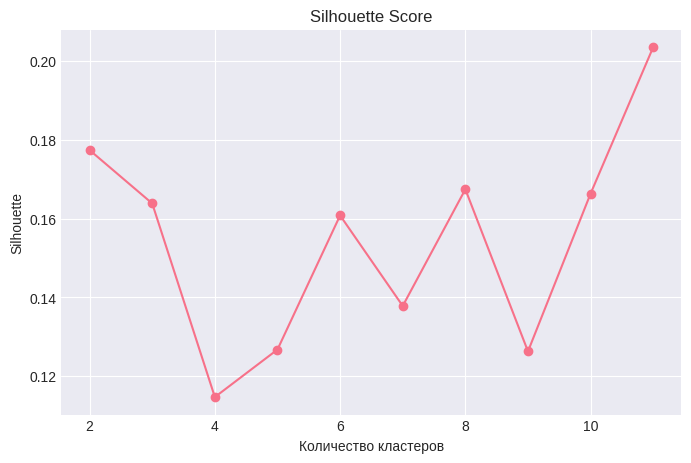

Лучшее k = 11


In [9]:
#Силуэт
plt.figure(figsize=(8,5))

plt.plot(
    ks,
    silhouettes,
    marker='o'
)

plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette")

plt.title("Silhouette Score")

plt.show()

best_k = ks[silhouettes.index(max(silhouettes))]

print("Лучшее k =", best_k)

In [10]:
#Обучение финальной модели
kmeans = KMeans(
    featuresCol="scaledFeatures",
    predictionCol="prediction",
    k=best_k,
    seed=42
)

model = kmeans.fit(scaled_data)

clustered = model.transform(scaled_data)

clustered.select("label", "prediction").show(10)

+-----+----------+
|label|prediction|
+-----+----------+
|    0|         1|
|    2|         9|
|    8|         3|
|    8|         3|
|    7|         2|
|    4|         9|
|    8|         3|
|    7|         6|
|    6|         5|
|    4|         9|
+-----+----------+
only showing top 10 rows



In [11]:
# Понижение размерности до двух компонент
pca = PCA(
    k=2,
    inputCol="scaledFeatures",
    outputCol="pcaFeatures"
)

pca_model = pca.fit(clustered)

pca_df = pca_model.transform(clustered)

# Извлечение координат X и Y из вектора PCA
extract_x = udf(lambda v: float(v[0]), FloatType())
extract_y = udf(lambda v: float(v[1]), FloatType())

final_export_df = (
    pca_df
    .withColumn("pca_x", extract_x("pcaFeatures"))
    .withColumn("pca_y", extract_y("pcaFeatures"))
    .select("label", "prediction", "pca_x", "pca_y")
)

final_export_df.show(10)

+-----+----------+----------+-----------+
|label|prediction|     pca_x|      pca_y|
+-----+----------+----------+-----------+
|    0|         1| 1.3663541|  2.4342477|
|    2|         9|  1.418678|-0.84626645|
|    8|         3|-1.3404704|  0.8217409|
|    8|         3| 0.5067138|  1.3121437|
|    7|         2|  3.613639|  -6.234302|
|    4|         9|  6.355183|   2.028359|
|    8|         3|-1.0182719|-0.21340945|
|    7|         6|0.32930112| -3.8642888|
|    6|         5|0.94341224|  4.4605975|
|    4|         9| 5.7838387|  1.9705476|
+-----+----------+----------+-----------+
only showing top 10 rows



In [12]:
#DataLens
import os



local_pdf = final_export_df.toPandas()

output_path = "model_results_for_datalens11.csv"

local_pdf.to_csv(output_path, index=False, encoding='utf-8')

print(f"Файл успешно сохранен локально.")
print(f"Имя файла для скачивания: {os.path.abspath(output_path)}")
print(f"Всего строк для выгрузки в DataLens: {len(local_pdf)}")

Файл успешно сохранен локально.
Имя файла для скачивания: /home/devops/Downloads/model_results_for_datalens11.csv
Всего строк для выгрузки в DataLens: 1797


#Остановка Spark

In [13]:
# Остановка SparkSession
spark.stop()
print("SparkSession остановлен")

SparkSession остановлен
